# GDGOC ITB AI - Hands On Module 5: Customer Segmentation with K-Means and PCA

In this notebook I segment the customers of a shopping mall with K-Means. I compare two versions of the clustering: one on the full preprocessed feature space and one after reducing the dimensionality with PCA. Then I pick the better result and turn each cluster into a customer persona that a marketing team can act on.

Dataset: `Mall_Customers.csv` (Kaggle, vjchoudhary7/customer-segmentation-tutorial-in-python). It has 200 customers and 5 columns:

| Column | Meaning |
| --- | --- |
| `CustomerID` | Unique customer identifier |
| `Gender` | Female / Male |
| `Age` | Age in years |
| `Annual Income (k$)` | Annual income in thousands of dollars |
| `Spending Score (1-100)` | Score assigned by the mall based on spending behaviour |

Roadmap:

1. Stage 1: exploratory data analysis and preprocessing (steps 1 and 2)
2. Stage 2: K-Means on the high-dimensional data, with K chosen by the Elbow Method and the Silhouette Score (steps 3 and 4)
3. Stage 3: PCA, then K-Means in the reduced space (steps 5 and 6)
4. Stage 4: comparison of both clusterings, profiling, personas and marketing insights (steps 7 to 9)
5. Bonus 1: Linear, Ridge and Lasso regression (L1 vs L2)
6. Bonus 2: hierarchical clustering as a sanity check
7. Bonus 3: K-Means initialization stability
8. Conclusion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# One fixed cluster palette reused in every cluster plot (cluster c always gets PALETTE[c])
PALETTE = sns.color_palette("tab10", 10)
NUM_COLS = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

## Stage 1: Exploratory Data Analysis and Preprocessing

## 1. Load and Explore the Data

### 1.1 Loading the dataset

In [2]:
df_raw = pd.read_csv("Mall_Customers.csv")
print("Original columns:", list(df_raw.columns))
if "Genre" in df_raw.columns:
    df_raw = df_raw.rename(columns={"Genre": "Gender"})

print("Shape:", df_raw.shape)
display(df_raw.head())
df_raw.info()
print("\nMissing values per column:")
print(df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())

Original columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


The dataset loads cleanly: 200 rows and 5 columns, no missing values in any column, and 0 duplicate rows, so I do not need any imputation or deduplication. The file I downloaded already names the gender column `Gender` (some copies of this dataset call it `Genre`), so no rename was needed; the code still handles the `Genre` variant. `Gender` is the only non-numeric column and will need encoding.

### 1.2 Dropping CustomerID

I keep an untouched copy, `df_original`, with `CustomerID` so I can attach cluster labels to the original customers in Stage 4. For the analysis I drop `CustomerID`, because it is an arbitrary identifier assigned in row order and says nothing about the customer. If I left it in as a feature, K-Means would treat customers with close IDs as similar and add a fake distance structure that has nothing to do with behaviour.

In [3]:
df_original = df_raw.copy()  # untouched copy (with CustomerID) used in Stage 4
df = df_raw.drop(columns="CustomerID")
print("Working columns:", list(df.columns))
df.head()

Working columns: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### 1.3 Descriptive statistics

In [4]:
display(df[NUM_COLS].describe().round(2))
print("Skewness:")
print(df[NUM_COLS].skew().round(3))

,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


Skewness:
Age                       0.486
Annual Income (k$)        0.322
Spending Score (1-100)   -0.047
dtype: float64


### 1.4 Distributions and outlier check

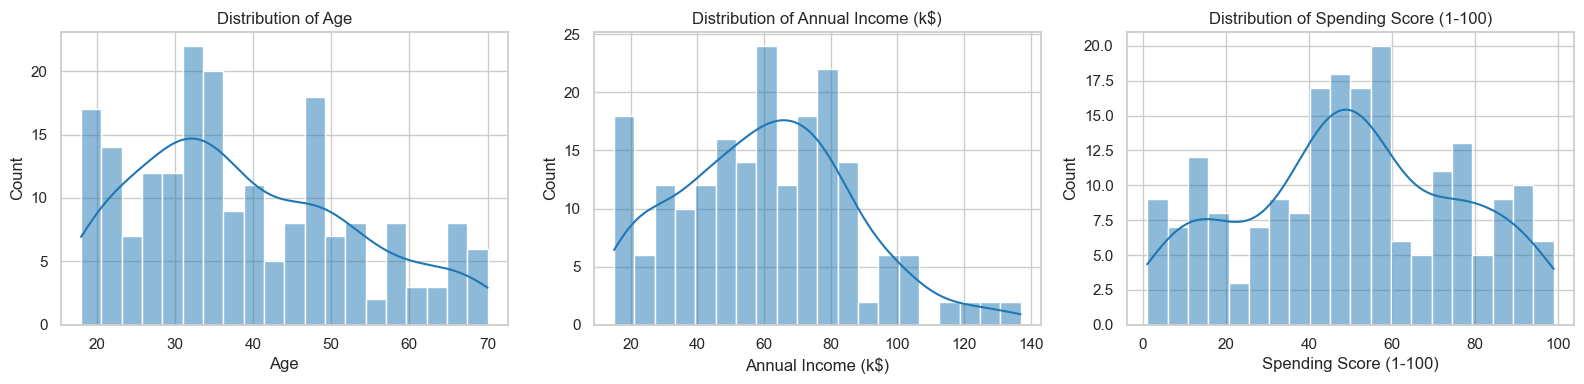

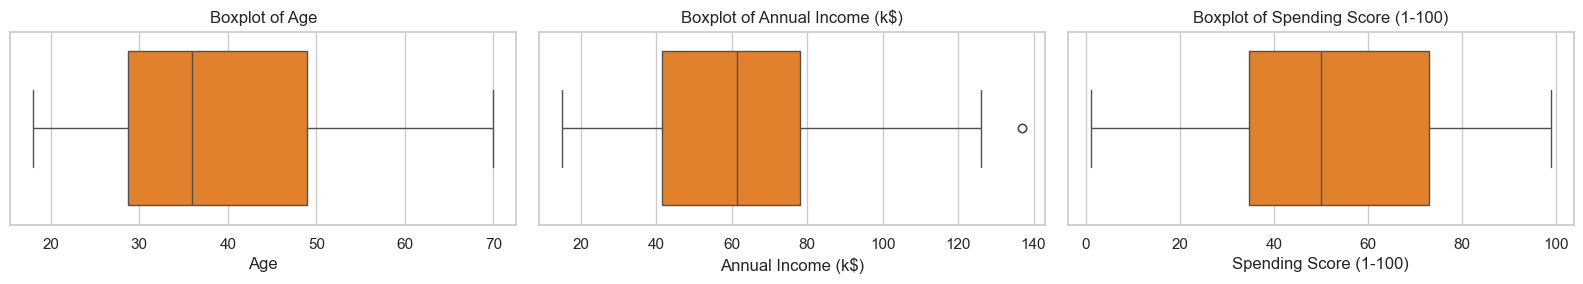

Outliers per feature (1.5 x IQR rule):
Age                       0
Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64

Rows flagged as outliers:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,Male,32,137,18
199,Male,30,137,83


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, NUM_COLS):
    sns.histplot(df[col], kde=True, bins=20, ax=ax, color=PALETTE[0])
    ax.set(title=f"Distribution of {col}", xlabel=col, ylabel="Count")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(x=df[col], ax=ax, color=PALETTE[1])
    ax.set(title=f"Boxplot of {col}", xlabel=col)
plt.tight_layout()
plt.show()

q1, q3 = df[NUM_COLS].quantile(0.25), df[NUM_COLS].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df[NUM_COLS] < q1 - 1.5 * iqr) | (df[NUM_COLS] > q3 + 1.5 * iqr)
print("Outliers per feature (1.5 x IQR rule):")
print(outlier_mask.sum())
print("\nRows flagged as outliers:")
display(df[outlier_mask.any(axis=1)])

What I see in each feature:

- `Age` ranges from 18 to 70 with a mean of 38.85 and a median of 36. It is moderately right-skewed (skewness 0.486): most customers are between their late 20s and late 40s (IQR 28.75 to 49), with a thinner tail of older customers. The boxplot shows no outliers.
- `Annual Income (k$)` ranges from 15k to 137k with a mean of 60.56k and a median of 61.5k, and is slightly right-skewed (skewness 0.322). The 1.5 x IQR rule flags 2 outliers, customers 199 and 200, both with an income of 137k.
- `Spending Score (1-100)` covers almost the whole scale (1 to 99) with mean 50.20 and median 50, and is essentially symmetric (skewness -0.047).

I keep the two income outliers. They are only just above the upper fence, they are plausible values rather than data errors, and removing 2 of 200 customers would throw away real high-income customers that a marketing team cares about. With only 200 rows, every customer matters.

### 1.5 Gender composition

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64


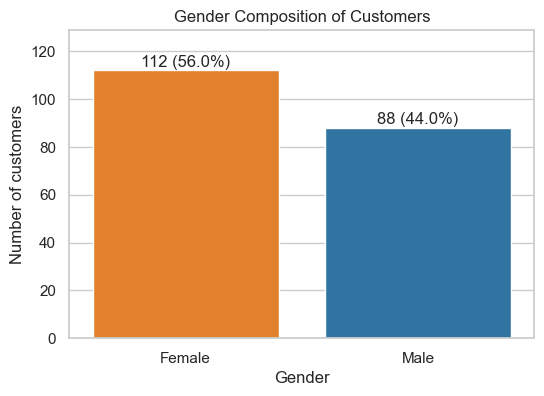

In [6]:
gender_counts = df["Gender"].value_counts()
gender_share = df["Gender"].value_counts(normalize=True)
print(gender_share.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Gender", order=gender_counts.index, hue="Gender",
              palette=PALETTE[:2], legend=False, ax=ax)
for i, g in enumerate(gender_counts.index):
    ax.text(i, gender_counts[g] + 1.5, f"{gender_counts[g]} ({gender_share[g]:.1%})", ha="center")
ax.set(title="Gender Composition of Customers", xlabel="Gender", ylabel="Number of customers",
       ylim=(0, gender_counts.max() * 1.15))
plt.show()

The customer base is 112 Female (56.0%) and 88 Male (44.0%). The split is slightly unbalanced but both groups are large, so gender can be used in profiling without one category being too rare.

### 1.6 Relationships between features

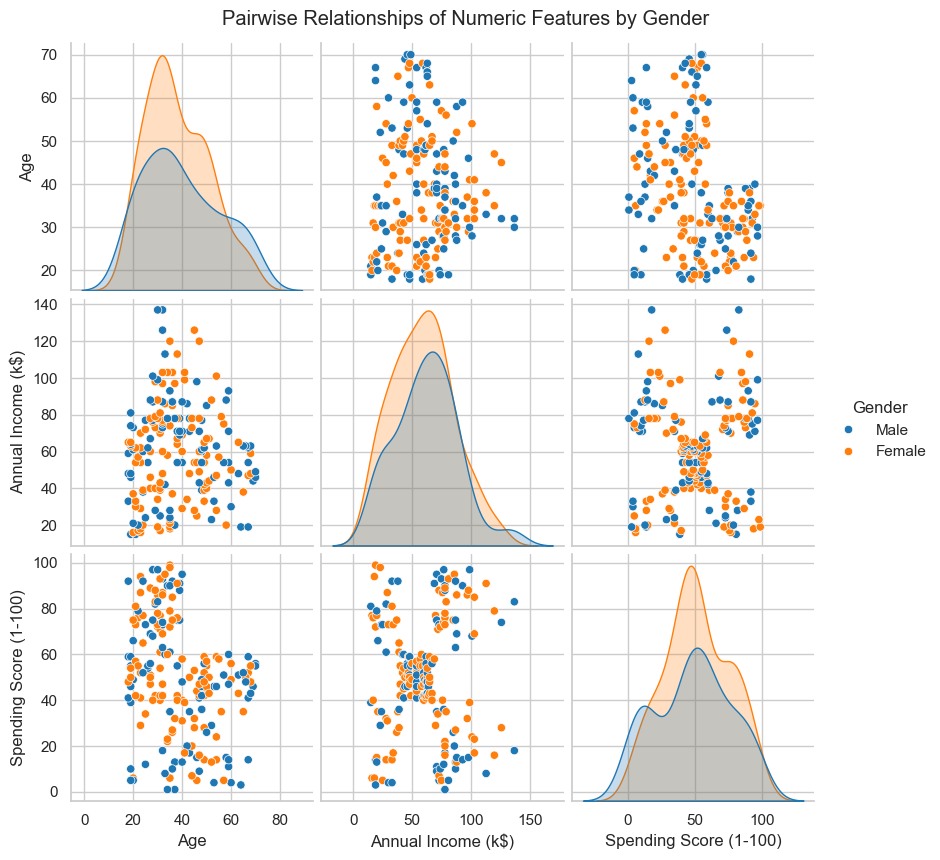

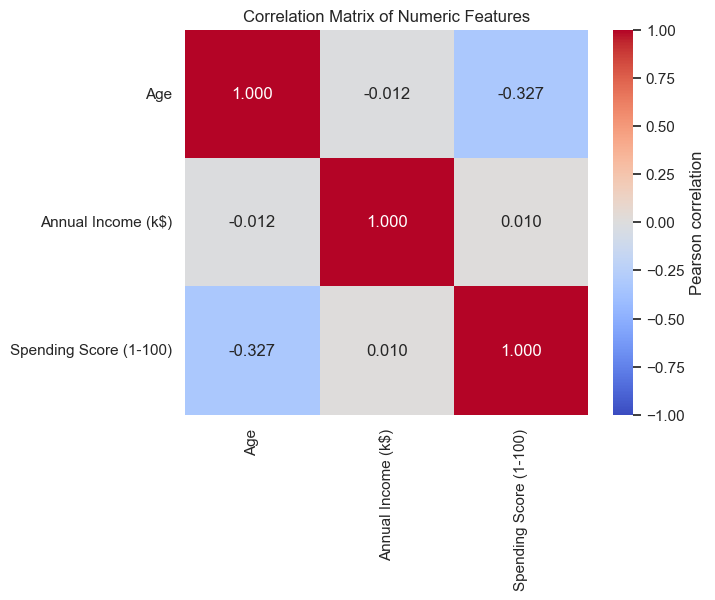

In [7]:
g = sns.pairplot(df, vars=NUM_COLS, hue="Gender", palette=PALETTE[:2], diag_kind="kde", height=2.8)
g.figure.suptitle("Pairwise Relationships of Numeric Features by Gender", y=1.02)
plt.show()

corr = df[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation Matrix of Numeric Features")
plt.show()

The pairplot already shows the most important pattern for segmentation. In `Annual Income (k$)` vs `Spending Score (1-100)` the points form clearly separated groups: a dense group in the middle (average income, average spending) and four groups in the corners (low income with low or high spending, high income with low or high spending). This is exactly the kind of structure K-Means is good at finding. Female and male customers overlap in every panel, so gender does not create its own groups.

The correlation heatmap confirms that the features are almost unrelated linearly:

- `Age` vs `Spending Score (1-100)`: -0.327, the only noticeable correlation (younger customers tend to spend more).
- `Annual Income (k$)` vs `Spending Score (1-100)`: 0.010, essentially zero. Income alone says almost nothing linear about spending, even though the scatter plot shows strong group structure. The relationship is grouped and non-linear, which is why clustering is more useful here than a linear model (see Bonus 1).
- `Age` vs `Annual Income (k$)`: -0.012, essentially zero.

So both `Age` and `Annual Income (k$)` are only weakly related to `Spending Score (1-100)` in a linear sense, and income is the weakest of the two.

## 2. Preprocessing

### 2.1 One-hot encoding Gender

In [8]:
gender_dummy = pd.get_dummies(df["Gender"], prefix="Gender", drop_first=True, dtype=int)
print("Categories:", sorted(df["Gender"].unique()))
print("Dummy column created:", list(gender_dummy.columns))
gender_dummy.value_counts()

Categories: ['Female', 'Male']
Dummy column created: ['Gender_Male']


Gender_Male
0              112
1               88
Name: count, dtype: int64

`pd.get_dummies(..., drop_first=True)` creates one column, `Gender_Male` (1 = Male, 0 = Female). `Female` comes first alphabetically, so it is dropped and becomes the baseline category. With only two categories, a `Gender_Female` column would always equal `1 - Gender_Male`, so keeping both would just duplicate the same information; `drop_first` removes that redundant column. The counts (112 zeros, 88 ones) match the gender composition from 1.5.

### 2.2 Scaling the numeric features

In [9]:
SCALED_NAMES = ["Age_scaled", "Income_scaled", "Spending_scaled"]
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[NUM_COLS]), columns=SCALED_NAMES, index=df.index)

print("Means after scaling:")
print(scaled.mean().round(6))
print("\nStandard deviations after scaling (ddof=0, as used by StandardScaler):")
print(scaled.std(ddof=0).round(6))

Means after scaling:
Age_scaled        -0.0
Income_scaled     -0.0
Spending_scaled   -0.0
dtype: float64

Standard deviations after scaling (ddof=0, as used by StandardScaler):
Age_scaled         1.0
Income_scaled      1.0
Spending_scaled    1.0
dtype: float64


### 2.3 Building the high-dimensional matrix X_high

In [10]:
X_high = pd.concat([scaled, gender_dummy], axis=1)
assert X_high.index.equals(df_original.index)  # same row order as the original data
print("X_high shape:", X_high.shape)
X_high.head()

X_high shape: (200, 4)


,Age_scaled,Income_scaled,Spending_scaled,Gender_Male
0,-1.424569,-1.738999,-0.434801,1
1,-1.281035,-1.738999,1.195704,1
2,-1.352802,-1.700830,-1.715913,0
3,-1.137502,-1.700830,1.040418,0
4,-0.563369,-1.662660,-0.395980,0


### 2.4 Preprocessing decisions

In [11]:
print("Variance of every column in X_high (ddof=0):")
print(X_high.var(ddof=0).round(4))

Variance of every column in X_high (ddof=0):
Age_scaled         1.0000
Income_scaled      1.0000
Spending_scaled    1.0000
Gender_Male        0.2464
dtype: float64


Why I preprocess this way:

- Scaling is required because K-Means assigns points using Euclidean distance. In raw units, `Annual Income (k$)` has a standard deviation of 26.26 and `Age` 13.97, so the feature with the largest spread would dominate the distances just because of its unit. After `StandardScaler`, every numeric feature has mean 0 and standard deviation 1 (verified in 2.2), so each one gets the same weight.
- I do not standardize the `Gender_Male` dummy. The task scales the numeric features and then combines them with the encoded column, and keeping the dummy as 0/1 also keeps it interpretable. The consequence is that its variance is only 0.2464 compared with 1.0000 for each scaled feature, so Gender has less influence on the distances than Age, Income or Spending Score. I accept this on purpose: the pairplot showed that gender does not separate the customers, so I do not want it to drive the clusters.
- "High-dimensional" here just means the full preprocessed feature space `X_high` (4 columns), as opposed to the PCA-reduced space of Stage 3. It is not high-dimensional in an absolute sense.

## Stage 2: Clustering on the High-Dimensional Data

## 3. Elbow Method and Silhouette Score

### 3.1 A reusable helper for choosing K

I write one helper, `evaluate_k`, that I reuse in Stage 3. For each K it fits `KMeans(n_clusters=k, n_init=10, random_state=42)` and records the WCSS (`inertia_`, the sum of squared distances from each point to its centroid) for K = 1 to 10, plus the average Silhouette Score for K = 2 to 10. The silhouette range starts at K = 2 because a point's silhouette compares its mean distance to its own cluster with its mean distance to the nearest other cluster. With K = 1 there is no other cluster, so the score is undefined.

In [12]:
K_RANGE = range(1, 11)


def evaluate_k(X, k_range=K_RANGE):
    """Fit K-Means for every K and return WCSS (all K) and Silhouette Score (K >= 2)."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
        sil = silhouette_score(X, km.labels_) if k >= 2 else np.nan
        rows.append({"K": k, "WCSS": km.inertia_, "Silhouette": sil})
    res = pd.DataFrame(rows).set_index("K")
    res["WCSS drop from K-1 (%)"] = -res["WCSS"].pct_change() * 100
    return res


def plot_elbow(res, space_name):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(res.index, res["WCSS"], marker="o", color=PALETTE[0], label="WCSS (inertia)")
    ax.set(title=f"Elbow Method: WCSS vs K ({space_name})", xlabel="Number of clusters K",
           ylabel="WCSS", xticks=list(res.index))
    ax.legend()
    plt.show()


def plot_silhouette_curve(res, space_name):
    sil = res["Silhouette"].dropna()
    best_k = sil.idxmax()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(sil.index, sil.values, marker="o", color=PALETTE[1], label="Silhouette Score")
    ax.scatter(best_k, sil.max(), s=250, facecolors="none", edgecolors="red", linewidths=2,
               label=f"Maximum: K = {best_k} ({sil.max():.4f})")
    ax.set(title=f"Silhouette Score vs K ({space_name})", xlabel="Number of clusters K",
           ylabel="Average Silhouette Score", xticks=list(sil.index))
    ax.legend()
    plt.show()


def cluster_sizes(X, ks):
    """Cluster sizes for several candidate K values, side by side."""
    return pd.DataFrame({
        f"K = {k}": pd.Series(KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)).value_counts().sort_index()
        for k in ks
    }).fillna(0).astype(int).rename_axis("Cluster")

### 3.2 Elbow Method (WCSS for K = 1 to 10)

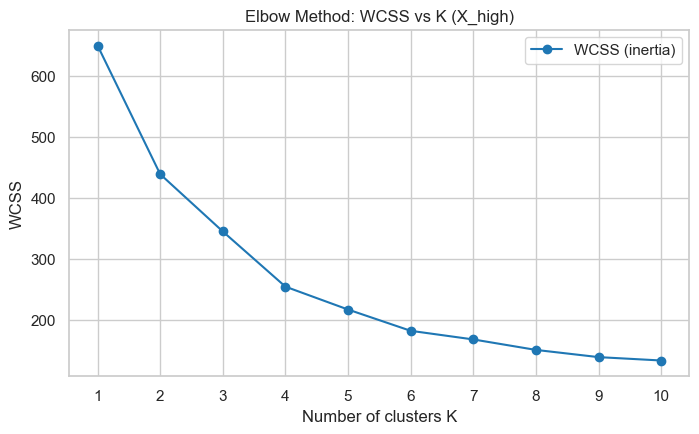

,WCSS,WCSS drop from K-1 (%)
K,,
1,649.28,NaN
2,438.52,32.46
3,344.68,21.40
4,254.28,26.23
5,216.78,14.75
6,181.95,16.07
7,167.82,7.77
8,150.66,10.22
9,138.86,7.83


In [13]:
res_high = evaluate_k(X_high)
plot_elbow(res_high, "X_high")
display(res_high[["WCSS", "WCSS drop from K-1 (%)"]].round(2))

### 3.3 Silhouette Score (K = 2 to 10)

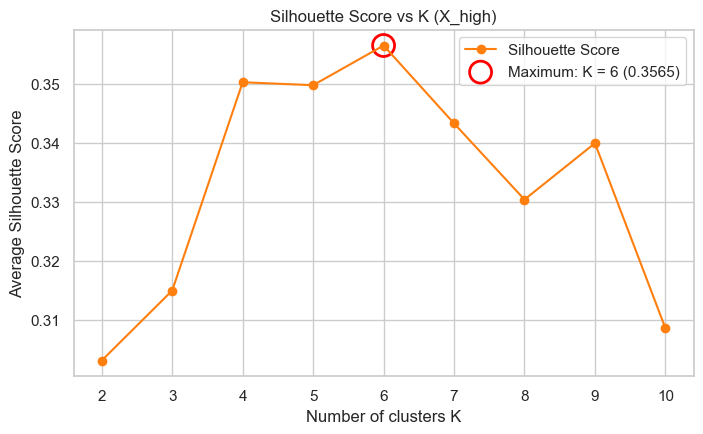

,Silhouette
K,
2,0.3032
3,0.3150
4,0.3503
5,0.3498
6,0.3565
7,0.3433
8,0.3304
9,0.3400
10,0.3087


Best K by Silhouette: 6


In [14]:
plot_silhouette_curve(res_high, "X_high")
display(res_high[["Silhouette"]].dropna().round(4))
print("Best K by Silhouette:", res_high["Silhouette"].idxmax())

### 3.4 Choosing K

In [15]:
top2_high = res_high["Silhouette"].nlargest(2).index.tolist()
print("Top 2 candidate K values by Silhouette:", top2_high)
cluster_sizes(X_high, sorted(top2_high))

Top 2 candidate K values by Silhouette: [6, 4]


,K = 4,K = 6
Cluster,,
0,40,45
1,57,39
2,38,21
3,65,34
4,0,23
5,0,38


Choosing K for `X_high`:

- Elbow: the WCSS drops steeply up to K = 6. The percentage decrease is 32.46% at K = 2, 21.40% at K = 3, 26.23% at K = 4, 14.75% at K = 5 and 16.07% at K = 6. After that the curve flattens: 7.77% at K = 7, 10.22% at K = 8, 7.83% at K = 9 and 3.99% at K = 10. So the elbow sits at about K = 6; adding a seventh cluster buys much less compactness.
- Silhouette: the maximum is at K = 6 (0.3565). K = 4 (0.3503) and K = 5 (0.3498) are close behind, while K = 2 (0.3032) and K = 10 (0.3087) are clearly worse.
- Cluster sizes for the top 2 candidates: K = 4 gives 40, 57, 38 and 65 customers, and K = 6 gives 45, 39, 21, 34, 23 and 38. With K = 6 the smallest cluster still has 21 customers (10.5%), which is large enough to be a useful marketing segment.

Both methods point to the same answer, so I choose K_high = 6. K = 4 would be a defensible simpler alternative since its silhouette is only 0.0062 lower, but at K = 4 the WCSS still drops sharply afterwards (14.75% and 16.07% at K = 5 and 6), which tells me it is merging groups that are actually distinct.

In [16]:
K_high = 6
print("K_high =", K_high)

K_high = 6


## 4. Final K-Means Model on X_high

### 4.1 and 4.2 Final model, Silhouette Score and cluster sizes

In [17]:
km_high = KMeans(n_clusters=K_high, n_init=10, random_state=42).fit(X_high)
labels_high = km_high.labels_
sil_high = silhouette_score(X_high, labels_high)
print(f"K_high = {K_high}")
print(f"Final Silhouette Score (X_high): {sil_high:.4f}")
print("Cluster sizes:")
print(pd.Series(labels_high).value_counts().sort_index().rename_axis("Cluster").rename("Size"))

K_high = 6
Final Silhouette Score (X_high): 0.3565
Cluster sizes:
Cluster
0    45
1    39
2    21
3    34
4    23
5    38
Name: Size, dtype: int64


### 4.3 Per-sample silhouette plot

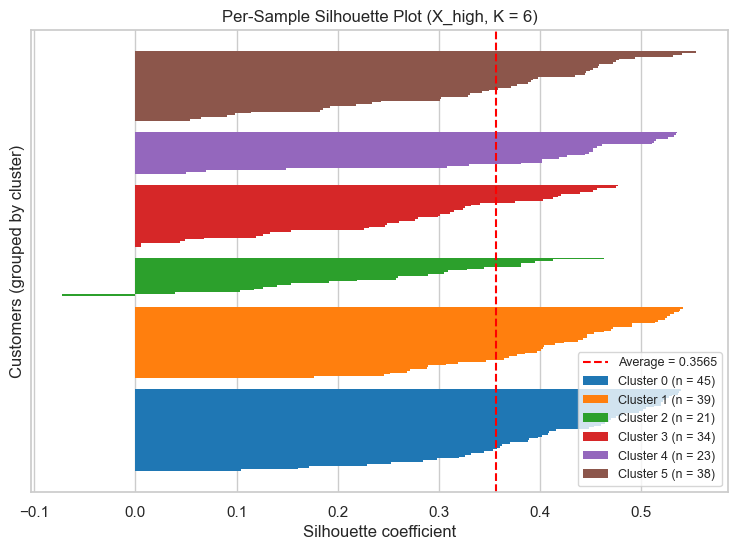

,Size,Mean,Min,Negative
Cluster,,,,
0,45,0.4092,0.1040,0
1,39,0.4122,0.1768,0
2,21,0.2449,-0.0723,1
3,34,0.2749,0.0056,0
4,23,0.4051,0.0497,0
5,38,0.3421,0.0539,0


In [18]:
def plot_silhouette_samples(X, labels, title):
    """Sorted per-sample silhouette bars grouped by cluster; returns a per-cluster summary."""
    values = silhouette_samples(X, labels)
    fig, ax = plt.subplots(figsize=(9, 6))
    y_lower = 0
    for c in np.unique(labels):
        vals = np.sort(values[labels == c])
        ax.barh(np.arange(y_lower, y_lower + len(vals)), vals, height=1.0, color=PALETTE[c],
                edgecolor="none", label=f"Cluster {c} (n = {len(vals)})")
        y_lower += len(vals) + 6  # gap between clusters
    ax.axvline(values.mean(), color="red", linestyle="--", label=f"Average = {values.mean():.4f}")
    ax.set(title=title, xlabel="Silhouette coefficient", ylabel="Customers (grouped by cluster)", yticks=[])
    ax.legend(loc="lower right", fontsize=9)
    plt.show()
    return (pd.DataFrame({"Cluster": labels, "Silhouette": values})
            .groupby("Cluster")["Silhouette"]
            .agg(Size="size", Mean="mean", Min="min", Negative=lambda s: int((s < 0).sum()))
            .round(4))


plot_silhouette_samples(X_high, labels_high, f"Per-Sample Silhouette Plot (X_high, K = {K_high})")

### 4.4 Interpreting the final Silhouette Score

The final model gives a Silhouette Score of 0.3565 with cluster sizes 45, 39, 21, 34, 23 and 38. By the Kaufman and Rousseeuw rule of thumb (0.71 to 1.00 strong, 0.51 to 0.70 reasonable, 0.26 to 0.50 weak, 0.25 or below no substantial structure), 0.3565 falls in the weak-structure band. I read this honestly: the clusters are real (the score is well above 0.25 and far from random), but they are not tight, well-separated blobs in all 4 dimensions. That is expected for customer data, where people form a continuum and the groups touch each other, especially around the middle segment.

The per-sample plot shows that the quality is uneven:

- Clusters 0, 1 and 4 are the most coherent (mean silhouettes 0.4092, 0.4122 and 0.4051), and cluster 5 is close behind (0.3421).
- Cluster 2 (21 customers) is the weakest, with a mean silhouette of 0.2449, and it contains the only negative value in the whole dataset (1 customer at -0.0723, i.e. slightly closer to another cluster). Cluster 3 is the second weakest (0.2749, minimum 0.0056).
- Apart from that one customer, every point has a positive silhouette, so there are no clusters full of badly assigned points; the weaker clusters simply have more customers near their boundaries.

## Stage 3: Clustering After PCA

## 5. Principal Component Analysis

### 5.1 Explained variance of all components

In [19]:
pca_full = PCA().fit(X_high)
pc_names = [f"PC{i}" for i in range(1, X_high.shape[1] + 1)]
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
var_table = pd.DataFrame({"Explained variance ratio": pca_full.explained_variance_ratio_,
                          "Cumulative explained variance": cumvar}, index=pc_names)
var_table.round(4)

,Explained variance ratio,Cumulative explained variance
PC1,0.4095,0.4095
PC2,0.3082,0.7177
PC3,0.2072,0.9249
PC4,0.0751,1.0000


### 5.2 Cumulative explained variance plot

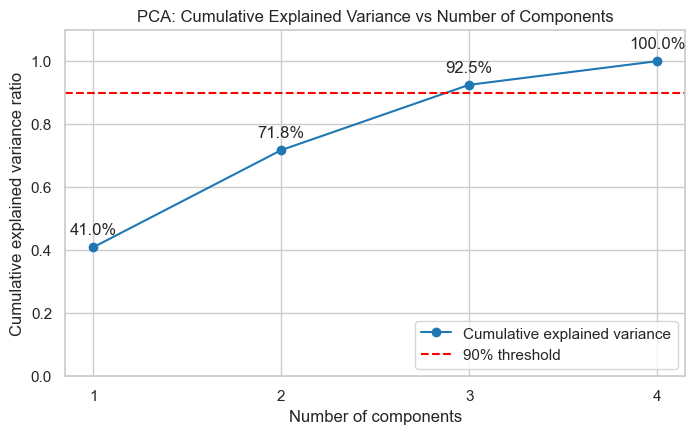

In [20]:
x = np.arange(1, len(cumvar) + 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, cumvar, marker="o", color=PALETTE[0], label="Cumulative explained variance")
ax.axhline(0.90, color="red", linestyle="--", label="90% threshold")
for xi, v in zip(x, cumvar):
    ax.annotate(f"{v:.1%}", (xi, v), textcoords="offset points", xytext=(0, 9), ha="center")
ax.set(title="PCA: Cumulative Explained Variance vs Number of Components",
       xlabel="Number of components", ylabel="Cumulative explained variance ratio", xticks=x, ylim=(0, 1.1))
ax.legend(loc="lower right")
plt.show()

### 5.3 Minimum number of components for at least 90% variance

In [21]:
n_pc = int(np.argmax(cumvar >= 0.90) + 1)
print(f"n_pc = {n_pc} components explain {cumvar[n_pc - 1]:.2%} of the variance "
      f"(out of {X_high.shape[1]} features)")

n_pc = 3 components explain 92.49% of the variance (out of 4 features)


### 5.4 Component loadings

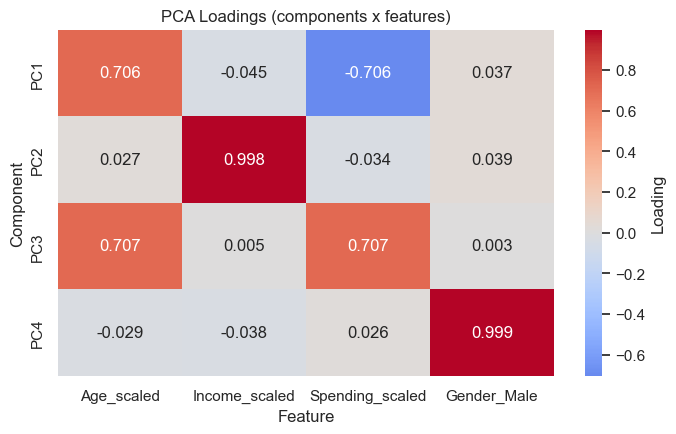

In [22]:
loadings = pd.DataFrame(pca_full.components_, index=pc_names, columns=X_high.columns)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(loadings, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Loading"})
ax.set(title="PCA Loadings (components x features)", xlabel="Feature", ylabel="Component")
plt.show()

### 5.5 Justifying n_pc

The first 3 components explain 92.49% of the variance (PC1 40.95%, PC2 30.82%, PC3 20.72%), so the minimum number of components for at least 90% is n_pc = 3. PC4 adds only the last 7.51%.

The loadings explain why:

- PC1 (40.95%): +0.706 `Age_scaled` and -0.706 `Spending_scaled`. It contrasts older customers with low spending against younger customers with high spending, which is the -0.327 Age and Spending correlation from 1.6.
- PC2 (30.82%): 0.998 on `Income_scaled`. It is essentially annual income.
- PC3 (20.72%): +0.707 `Age_scaled` and +0.707 `Spending_scaled`. It is the other combination of age and spending, where the two move together.
- PC4 (7.51%): 0.999 on `Gender_Male`. It is essentially the gender dummy.

Because n_pc = 3 is smaller than the 4 features, PCA is a real reduction here and not just a rotation. What it discards is almost exactly the Gender dimension, which had the smallest variance (0.2464) because I left it unscaled. Clustering on `X_pca` is therefore close to clustering on scaled Age, Income and Spending Score only, and I expect a result similar to Stage 2 (where gender already had little influence), though not necessarily identical.

## 6. Clustering in the PCA Space

### 6.1 Projecting X_high onto the retained components

In [23]:
pca = PCA(n_components=n_pc).fit(X_high)
X_pca = pd.DataFrame(pca.transform(X_high), columns=pc_names[:n_pc], index=X_high.index)
print("X_pca shape:", X_pca.shape)
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")
X_pca.head()

X_pca shape: (200, 3)
Variance retained: 0.9249


,PC1,PC2,PC3
0,-0.600438,-1.737179,-1.322247
1,-1.649886,-1.789124,-0.067789
2,0.315381,-1.692772,-2.179818
3,-1.477989,-1.781317,-0.078518
4,-0.060545,-1.678691,-0.688083


### 6.2 Elbow Method and Silhouette Score on X_pca

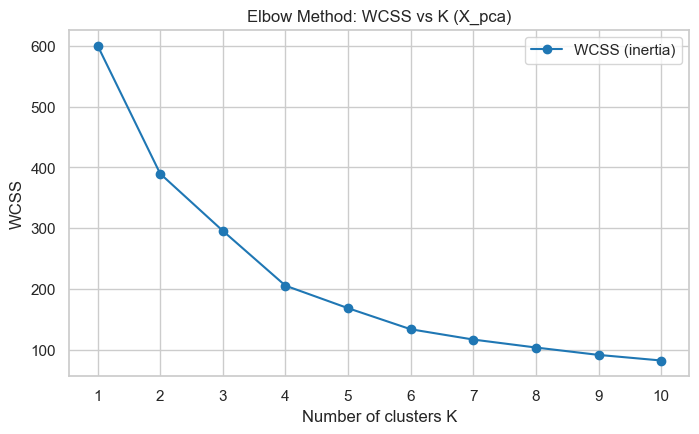

,WCSS,WCSS drop from K-1 (%)
K,,
1,600.54,NaN
2,389.82,35.09
3,295.85,24.10
4,205.68,30.48
5,168.65,18.00
6,134.01,20.54
7,117.06,12.65
8,103.97,11.18
9,91.84,11.67


In [24]:
res_pca = evaluate_k(X_pca)
plot_elbow(res_pca, "X_pca")
display(res_pca[["WCSS", "WCSS drop from K-1 (%)"]].round(2))

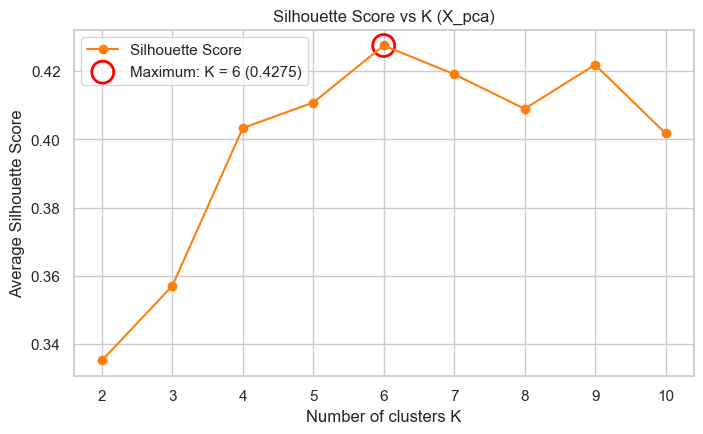

,Silhouette
K,
2,0.3352
3,0.3571
4,0.4033
5,0.4108
6,0.4275
7,0.4191
8,0.4090
9,0.4219
10,0.4018


Best K by Silhouette: 6
Top 2 candidate K values by Silhouette: [6, 9]


,K = 6,K = 9
Cluster,,
0,45,39
1,38,32
2,39,32
3,21,14
4,24,22
5,33,11
6,0,20
7,0,10
8,0,20


In [25]:
plot_silhouette_curve(res_pca, "X_pca")
display(res_pca[["Silhouette"]].dropna().round(4))
print("Best K by Silhouette:", res_pca["Silhouette"].idxmax())
top2_pca = res_pca["Silhouette"].nlargest(2).index.tolist()
print("Top 2 candidate K values by Silhouette:", top2_pca)
cluster_sizes(X_pca, sorted(top2_pca))

### 6.3 Choosing K for the PCA space

Choosing K for `X_pca`, independently of Stage 2:

- Elbow: the percentage decrease in WCSS is 35.09% at K = 2, 24.10% at K = 3, 30.48% at K = 4, 18.00% at K = 5 and 20.54% at K = 6. From K = 7 onwards the drops level off at 12.65%, 11.18%, 11.67% and 10.02%. The elbow is less sharp than in `X_high`, but the last big gain happens at K = 6.
- Silhouette: the maximum is at K = 6 (0.4275). The next best are K = 9 (0.4219) and K = 7 (0.4191).
- Cluster sizes for the top 2 candidates: K = 6 gives 45, 38, 39, 21, 24 and 33, while K = 9 splits the data into smaller groups down to 10 and 11 customers.

I choose K_pca = 6. It has the highest silhouette and matches the end of the steep part of the Elbow curve. K = 9 scores almost as well (0.4219), but it only fragments existing segments into groups of 10 to 11 customers, which are too small to be worth a separate marketing strategy. It is a coincidence of the data that this is the same K as in Stage 2; I reached it from the `X_pca` numbers above.

In [26]:
K_pca = 6
print("K_pca =", K_pca)

K_pca = 6


### 6.4 Final K-Means model on X_pca

In [27]:
km_pca = KMeans(n_clusters=K_pca, n_init=10, random_state=42).fit(X_pca)
labels_pca = km_pca.labels_
sil_pca = silhouette_score(X_pca, labels_pca)
print(f"K_pca = {K_pca}")
print(f"Final Silhouette Score (X_pca): {sil_pca:.4f}")
print("Cluster sizes:")
print(pd.Series(labels_pca).value_counts().sort_index().rename_axis("Cluster").rename("Size"))

K_pca = 6
Final Silhouette Score (X_pca): 0.4275
Cluster sizes:
Cluster
0    45
1    38
2    39
3    21
4    24
5    33
Name: Size, dtype: int64


### 6.5 Clusters in the PC1 vs PC2 plane

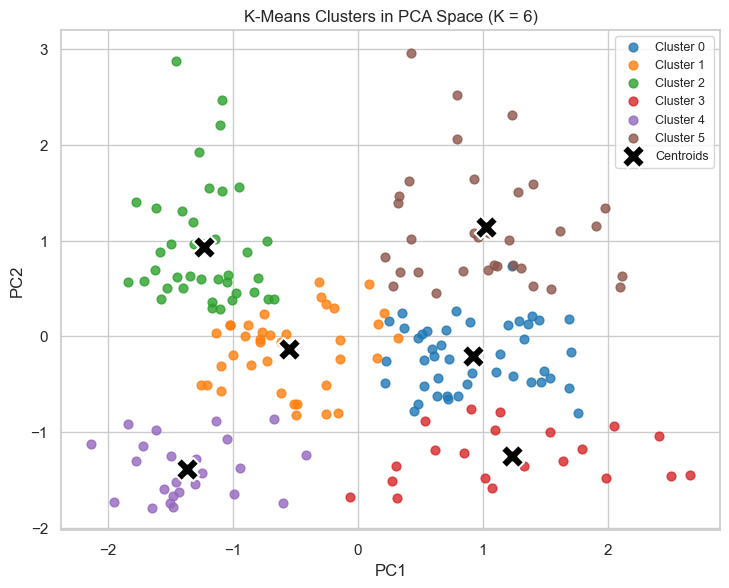

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for c in range(K_pca):
    m = labels_pca == c
    ax.scatter(X_pca.loc[m, "PC1"], X_pca.loc[m, "PC2"], color=PALETTE[c], s=40, alpha=0.8, label=f"Cluster {c}")
ax.scatter(km_pca.cluster_centers_[:, 0], km_pca.cluster_centers_[:, 1], marker="X", s=280,
           c="black", edgecolors="white", linewidths=1.5, label="Centroids")
ax.set(title=f"K-Means Clusters in PCA Space (K = {K_pca})", xlabel="PC1", ylabel="PC2")
ax.legend(loc="best", fontsize=9)
plt.show()

In the PC1 vs PC2 plane the six clusters separate mostly along the two axes: PC2 (income) splits the high-income clusters 2 and 5 at the top from the low-income clusters 3 and 4 at the bottom, and PC1 (age minus spending) splits each income level into a young, high-spending side (left) and an older, low-spending side (right). Clusters 0 and 1 sit in the middle-income band and are separated by PC1. Some clusters touch (for example 0 and 5, or 0 and 3) because this plot shows only 2 of the 3 dimensions used; PC3 carries the remaining 20.72% of the variance and separates part of that overlap.

### 6.6 A fair comparison of Silhouette Scores

In [29]:
sil_pca_in_high = silhouette_score(X_high, labels_pca)
sil_compare = pd.DataFrame({
    "Labels": [f"Stage 2 K-Means (K = {K_high})", f"Stage 3 K-Means (K = {K_pca})", f"Stage 3 K-Means (K = {K_pca})"],
    "Evaluated in": ["X_high", "X_pca", "X_high"],
    "Silhouette Score": [sil_high, sil_pca, sil_pca_in_high],
})
sil_compare.round(4)

,Labels,Evaluated in,Silhouette Score
0,Stage 2 K-Means (K = 6),X_high,0.3565
1,Stage 3 K-Means (K = 6),X_pca,0.4275
2,Stage 3 K-Means (K = 6),X_high,0.3570


The Stage 3 score (0.4275 in `X_pca`) looks much better than the Stage 2 score (0.3565 in `X_high`), but that comparison is not fair. PCA dropped PC4, which is almost exactly the Gender dimension. Inside each cluster both genders are mixed, so in `X_high` that 0/1 dimension adds within-cluster distance that no cluster can remove. Without it, the same customers look tighter and the silhouette rises.

When I evaluate the Stage 3 labels in the same space as Stage 2 (`X_high`), the score is 0.3570, practically identical to Stage 2's 0.3565 (a difference of 0.0005). So the higher PCA score comes from measuring in a different space, not from a better partition. The two clusterings are almost the same, which I confirm with the crosstab in 7.3.

## Stage 4: Comparison and Segment Profiling

## 7. Comparing the Two Clusterings

### 7.1 Attaching both label sets to the original data

In [30]:
assert df_original.index.equals(X_high.index) and df_original.index.equals(X_pca.index)
df_original["Cluster_High"] = labels_high
df_original["Cluster_PCA"] = labels_pca
df_original.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_High,Cluster_PCA
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,4,4
2,3,Female,20,16,6,2,3
3,4,Female,23,16,77,4,4
4,5,Female,31,17,40,2,3


### 7.2 Annual Income vs Spending Score, side by side

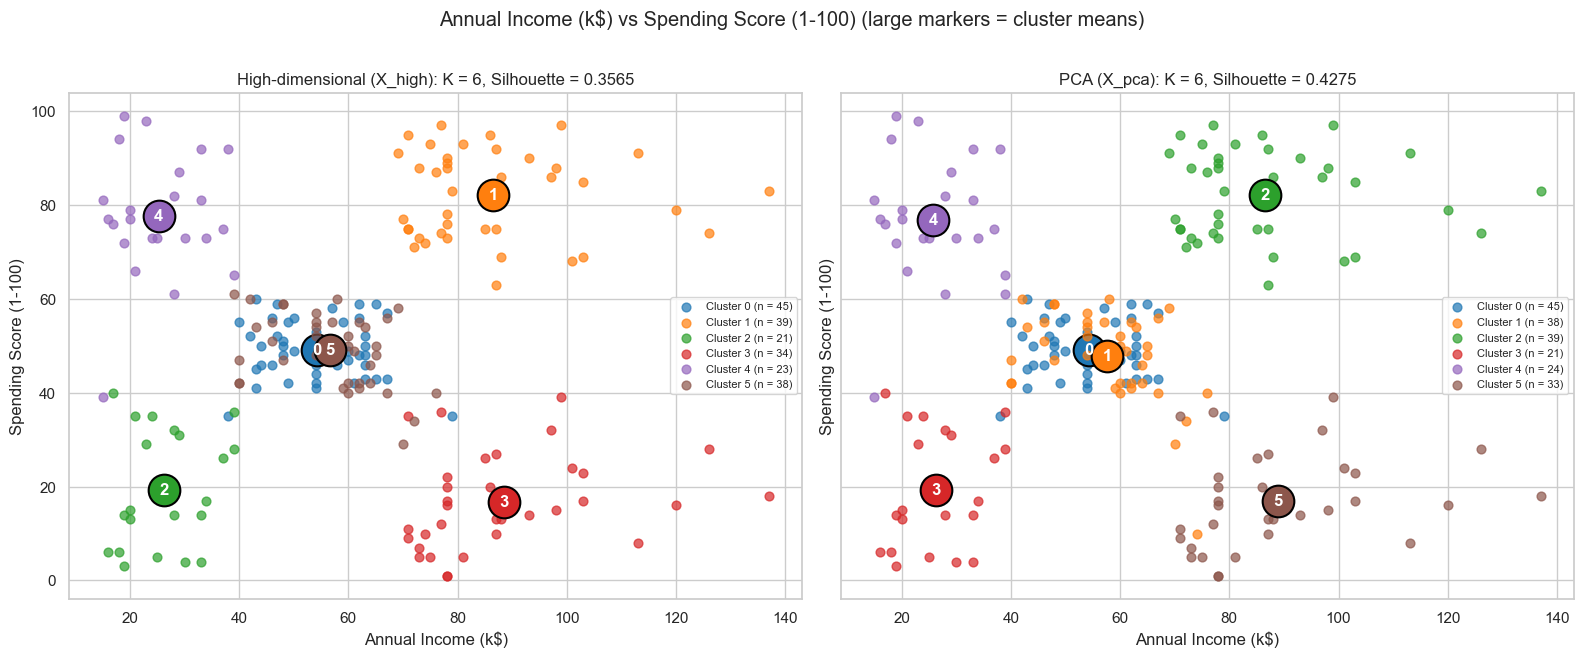

In [31]:
def plot_side_by_side(x_col, y_col):
    """Left: Stage 2 labels, right: Stage 3 labels, with each cluster's mean as a labeled marker."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
    setups = [("Cluster_High", K_high, sil_high, "High-dimensional (X_high)"),
              ("Cluster_PCA", K_pca, sil_pca, "PCA (X_pca)")]
    for ax, (col, k, sil, name) in zip(axes, setups):
        for c in range(k):
            sub = df_original[df_original[col] == c]
            ax.scatter(sub[x_col], sub[y_col], color=PALETTE[c], s=40, alpha=0.7, label=f"Cluster {c} (n = {len(sub)})")
            mx, my = sub[x_col].mean(), sub[y_col].mean()
            ax.scatter(mx, my, color=PALETTE[c], s=520, edgecolors="black", linewidths=1.5)
            ax.text(mx, my, str(c), ha="center", va="center", fontsize=12, fontweight="bold", color="white")
        ax.set(title=f"{name}: K = {k}, Silhouette = {sil:.4f}", xlabel=x_col, ylabel=y_col)
        ax.legend(loc="best", fontsize=8)
    fig.suptitle(f"{x_col} vs {y_col} (large markers = cluster means)", y=1.01)
    plt.tight_layout()
    plt.show()


plot_side_by_side("Annual Income (k$)", "Spending Score (1-100)")

Both panels show the same picture in `Annual Income (k$)` vs `Spending Score (1-100)`: four corner groups (low income and high spending, low income and low spending, high income and high spending, high income and low spending) and a middle group of average income and spending. In both clusterings the middle group is split into two clusters whose means sit almost on top of each other (clusters 0 and 5 on the left, clusters 0 and 1 on the right). In this plot they look like one overlapping cloud, which is exactly why they pull the silhouette down. The only visible difference between the panels is the colours and numbers, and cluster numbers are arbitrary.

### 7.3 Agreement between the two clusterings

In [32]:
display(pd.crosstab(df_original["Cluster_High"], df_original["Cluster_PCA"]))
ari_high_pca = adjusted_rand_score(labels_high, labels_pca)
print(f"Adjusted Rand Index (Cluster_High vs Cluster_PCA): {ari_high_pca:.4f}")

Cluster_PCA,0,1,2,3,4,5
Cluster_High,,,,,,
0,45,0,0,0,0,0
1,0,0,39,0,0,0
2,0,0,0,21,0,0
3,0,1,0,0,0,33
4,0,0,0,0,23,0
5,0,37,0,0,1,0


Adjusted Rand Index (Cluster_High vs Cluster_PCA): 0.9772


Cluster numbers are arbitrary: K-Means labels its clusters in whatever order its centroids end up, so the same group can be cluster 5 in one model and cluster 1 in the other. I therefore judge agreement from the crosstab and the Adjusted Rand Index, not from matching colours.

The crosstab is almost a perfect one-to-one mapping: High 0 = PCA 0 (45), High 1 = PCA 2 (39), High 2 = PCA 3 (21), High 4 = PCA 4 (23), High 3 = PCA 5 (33 of 34) and High 5 = PCA 1 (37 of 38). Only 2 of 200 customers change cluster. The Adjusted Rand Index is 0.9772 (1 means identical partitions, about 0 means chance-level agreement), so the two approaches found essentially the same segments.

### 7.4 Age vs Spending Score, side by side

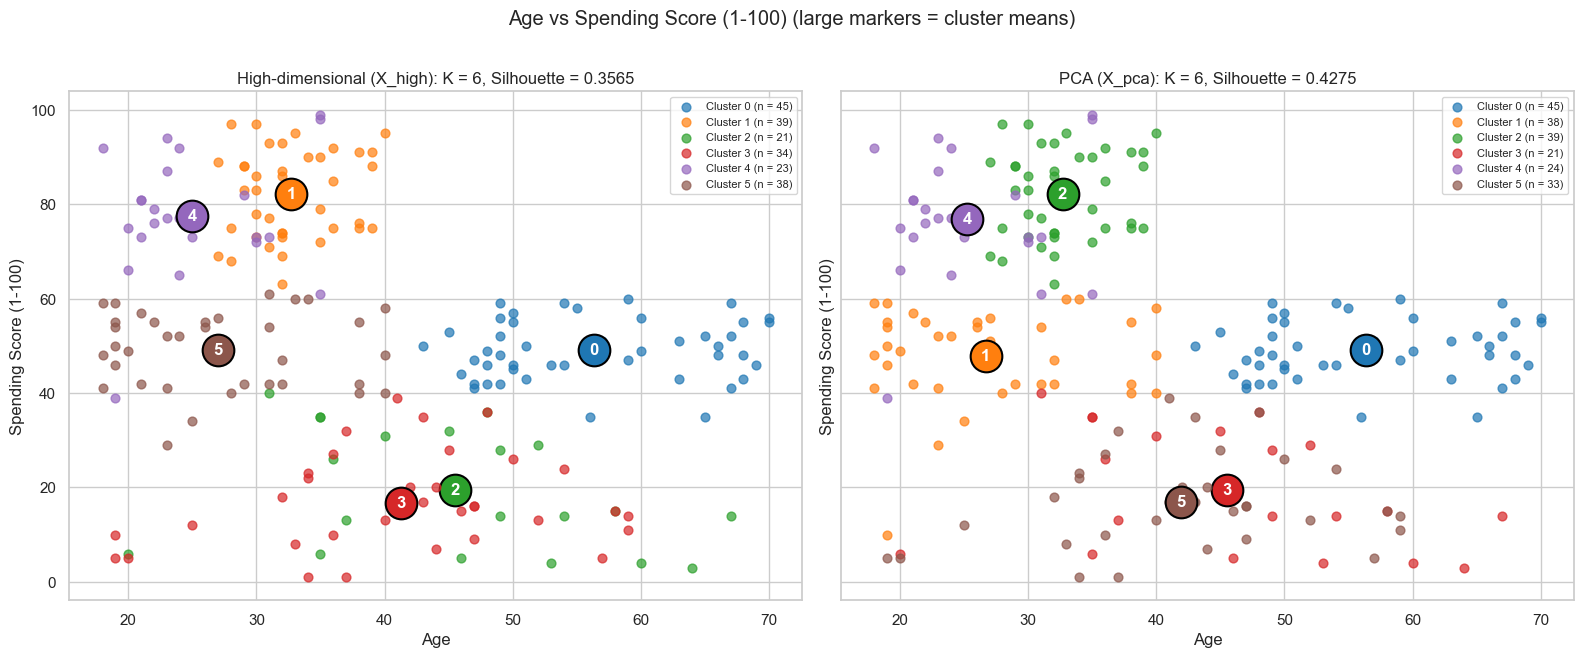

In [33]:
plot_side_by_side("Age", "Spending Score (1-100)")

Age vs `Spending Score (1-100)` shows what the income plot hides. The two middle clusters that overlapped in 7.2 (High 0 and High 5) are clearly separated by age: High 0 contains older customers (mean age 56.3) and High 5 younger customers (mean age 27.0), with almost the same income and spending. The two high-spending clusters (High 1 and High 4) overlap in this plot but were separated by income in 7.2, and the two low-spending clusters (High 2 and High 3) overlap here too but differ strongly in income. So every cluster is separated by at least one of the three features, and the six segments need all three to be told apart.

## 8. Choosing the Better Clustering and Profiling It

### 8.1 Decision

I choose the Stage 2 clustering (`Cluster_High`).

- (a) Silhouette Scores: the raw scores (0.3565 in `X_high` vs 0.4275 in `X_pca`) are not comparable because they were measured in different spaces. In the same space, the scores are 0.3565 (Stage 2) and 0.3570 (Stage 3 labels), a difference of 0.0005, which comes from only 2 customers changing cluster. Neither approach is meaningfully better on this metric.
- (b) Visual separation: the side-by-side plots in 7.2 and 7.4 are practically indistinguishable, with the same six groups and the same overlaps.
- (c) Interpretability: both give the same six interpretable segments. Stage 2 clusters directly on the original (scaled) features, including gender, without discarding the 7.51% of variance that PCA drops, and it needs one fewer transformation to explain to a marketing team.

Since the metrics and the plots are tied, I prefer the simpler model that uses all the information. PCA is still useful here as a check: it confirms that the segments are driven by Age, Income and Spending Score and not by gender.

In [34]:
chosen = "Cluster_High"
print("Chosen clustering:", chosen)

Chosen clustering: Cluster_High


### 8.2 Cluster profiles

In [35]:
profile = df_original.groupby(chosen)[NUM_COLS].mean().round(1)
display(profile)

support = df_original.groupby(chosen).agg(
    Size=("Age", "size"),
    Female_share=("Gender", lambda s: (s == "Female").mean()),
)
support["Share of customers (%)"] = (support["Size"] / len(df_original) * 100).round(1)
support["Female share (%)"] = (support.pop("Female_share") * 100).round(1)
support

,Age,Annual Income (k$),Spending Score (1-100)
Cluster_High,,,
0,56.3,54.3,49.1
1,32.7,86.5,82.1
2,45.5,26.3,19.4
3,41.3,88.5,16.8
4,25.0,25.3,77.6
5,27.0,56.7,49.1


,Size,Share of customers (%),Female share (%)
Cluster_High,,,
0,45,22.5,57.8
1,39,19.5,53.8
2,21,10.5,61.9
3,34,17.0,41.2
4,23,11.5,56.5
5,38,19.0,65.8


### 8.3 Visual profile

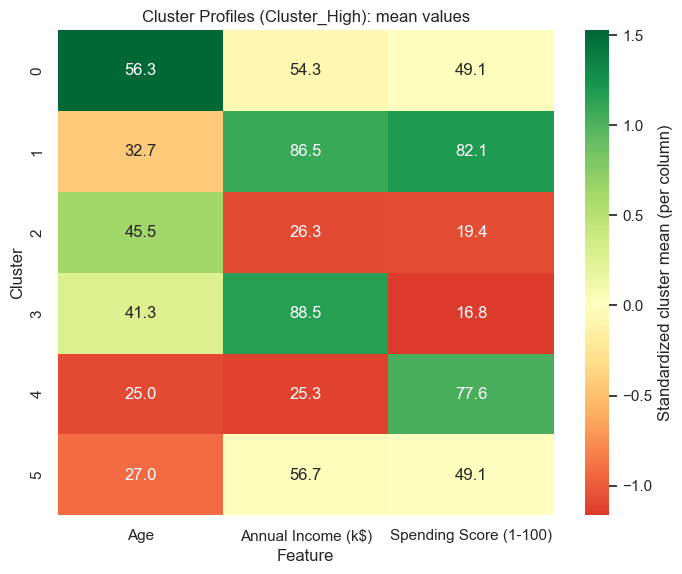

In [36]:
z = (profile - profile.mean()) / profile.std()  # colour standardized per column
fig, ax = plt.subplots(figsize=(8, 0.8 * len(profile) + 1.5))
sns.heatmap(z, annot=profile, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "Standardized cluster mean (per column)"})
ax.set(title=f"Cluster Profiles ({chosen}): mean values", xlabel="Feature", ylabel="Cluster")
plt.show()

The heatmap makes the six segments easy to compare. The colour is standardized per column, and the annotations are the real means:

- `Spending Score (1-100)` splits the clusters into high spenders (clusters 1 and 4, at 82.1 and 77.6), average spenders (clusters 0 and 5, both 49.1) and low spenders (clusters 2 and 3, at 19.4 and 16.8).
- `Annual Income (k$)` then splits each pair: high income in clusters 1 and 3 (86.5k and 88.5k), average in 0 and 5 (54.3k and 56.7k), and low in 2 and 4 (26.3k and 25.3k).
- `Age` separates the two average clusters (56.3 vs 27.0), and shows that the high spenders are young (32.7 and 25.0).

Cluster 3 is the only segment with a male majority (41.2% female, against 56.0% female overall). Cluster 5 has the highest female share (65.8%).

## 9. Personas and Marketing Insights

### 9.1 Personas

- Cluster 0, Mature Moderate Spenders: the largest segment, with 45 customers (22.5%). They are the oldest group (mean age 56.3), with an average income of 54.3k and an average spending score of 49.1. They are steady, middle-of-the-road shoppers.
- Cluster 1, Affluent Big Spenders: 39 customers (19.5%), mean age 32.7, a high income of 86.5k and the highest spending score (82.1). These are young, well-off customers who spend in line with their income and are the mall's most valuable segment.
- Cluster 2, Budget-Conscious Shoppers: 21 customers (10.5%), mean age 45.5, the lowest income band (26.3k) and a low spending score of 19.4. They spend carefully because their budget is tight. This is also the least cohesive cluster (mean silhouette 0.2449).
- Cluster 3, Careful High-Earners: 34 customers (17.0%), mean age 41.3, the highest income (88.5k) but the lowest spending score (16.8). They can afford much more than they spend at the mall. It is the only male-majority segment (41.2% female).
- Cluster 4, Young Impulsive Spenders: 23 customers (11.5%), the youngest group (mean age 25.0), with a low income of 25.3k but a high spending score of 77.6. They spend far more than their income would suggest.
- Cluster 5, Young Mainstream Shoppers: 38 customers (19.0%), mean age 27.0, an average income of 56.7k and an average spending score of 49.1. They are young, average-income customers with average spending, and the most female segment (65.8%).

### 9.2 Three actionable marketing insights

1. Protect the Affluent Big Spenders (cluster 1). They have a high income (86.5k) and the highest spending score (82.1), and they make up 19.5% of customers (39 people), so they are likely to generate a large share of revenue. Action: offer them a tiered VIP loyalty program with early access to new collections, premium-brand events and personalised rewards, so that they keep spending at the mall instead of switching to competitors.
2. Convert the Careful High-Earners (cluster 3). They earn the most of any segment (88.5k) but have the lowest spending score (16.8), so they are the largest untapped potential (34 customers, 17.0%). Action: run a targeted campaign built around quality, exclusivity and value (for example premium product trials or first-purchase offers on high-end stores), with a message aimed at a male-majority audience (58.8% male). Measure success by whether their spending score rises, rather than assuming the campaign will work.
3. Engage the Young Impulsive Spenders (cluster 4) sustainably. They are the youngest group (mean age 25.0) and spend heavily (77.6) on a low income (25.3k). Action: target them with affordable bundles, student and young-adult discounts and a points program that rewards frequent small purchases. That keeps them engaged without pushing premium prices they cannot sustain, and builds loyalty early so that some of them may grow into the Affluent Big Spenders segment as their income rises.

## Bonus 1: Regularization in Practice

### B1.1 Goal

Here I look at how L1 (Lasso) and L2 (Ridge) regularization change the coefficients of a linear model. This is a supervised side experiment, independent of the clustering: I predict `Spending Score (1-100)` from `Annual Income (k$)` and `Age`.

I put a `StandardScaler` and the model in one pipeline. The penalty acts directly on the size of the coefficients, so both features must be on the same scale; otherwise the penalty would hit the feature with the smaller unit harder, and the coefficients would not be comparable. After scaling, each coefficient means the change in Spending Score for a one-standard-deviation change in that feature.

### B1.2 Setup

In [37]:
X_reg = df_original[["Annual Income (k$)", "Age"]]
y_reg = df_original["Spending Score (1-100)"]
ALPHAS = [0.01, 0.1, 1, 10, 100]


def fit_reg(model):
    """Scale inside a pipeline so both coefficients are penalized on the same scale."""
    pipe = make_pipeline(StandardScaler(), model).fit(X_reg, y_reg)
    est = pipe[-1]
    return {"coef_Income": est.coef_[0], "coef_Age": est.coef_[1],
            "intercept": est.intercept_, "R2": pipe.score(X_reg, y_reg)}

### B1.3 Plain Linear Regression

In [38]:
lin = fit_reg(LinearRegression())
print(f"Coefficient (standardized Income): {lin['coef_Income']:.4f}")
print(f"Coefficient (standardized Age):    {lin['coef_Age']:.4f}")
print(f"Intercept: {lin['intercept']:.4f}")
print(f"R^2: {lin['R2']:.4f}")

Coefficient (standardized Income): 0.1506
Coefficient (standardized Age):    -8.4271
Intercept: 50.2000
R^2: 0.1071


### B1.4 Ridge and Lasso over the alpha grid

In [39]:
rows = [{"Model": "LinearRegression", "alpha": np.nan, **lin}]
for a in ALPHAS:
    rows.append({"Model": "Ridge", "alpha": a, **fit_reg(Ridge(alpha=a))})
for a in ALPHAS:
    rows.append({"Model": "Lasso", "alpha": a, **fit_reg(Lasso(alpha=a, max_iter=100_000))})
reg_table = pd.DataFrame(rows)[["Model", "alpha", "coef_Income", "coef_Age", "R2"]]
reg_table.round(4)

,Model,alpha,coef_Income,coef_Age,R2
0,LinearRegression,NaN,0.1506,-8.4271,0.1071
1,Ridge,0.01,0.1506,-8.4267,0.1071
2,Ridge,0.10,0.1506,-8.4229,0.1071
3,Ridge,1.00,0.1504,-8.3852,0.1071
4,Ridge,10.00,0.1482,-8.0259,0.1069
5,Ridge,100.00,0.1236,-5.6183,0.0952
6,Lasso,0.01,0.1407,-8.4173,0.1071
7,Lasso,0.10,0.0518,-8.3284,0.1071
8,Lasso,1.00,0.0000,-7.4290,0.1056
9,Lasso,10.00,0.0000,0.0000,0.0000


### B1.5 Coefficients vs alpha

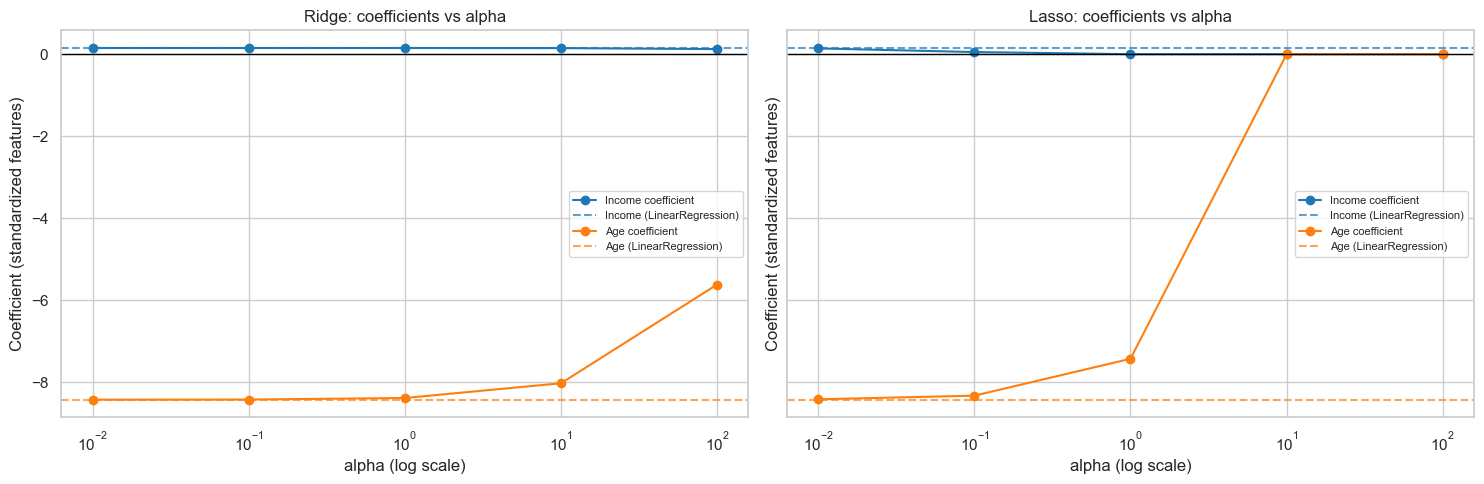

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, name in zip(axes, ["Ridge", "Lasso"]):
    sub = reg_table[reg_table["Model"] == name]
    for i, (feat, label) in enumerate([("coef_Income", "Income"), ("coef_Age", "Age")]):
        ax.plot(sub["alpha"], sub[feat], marker="o", color=PALETTE[i], label=f"{label} coefficient")
        ax.axhline(lin[feat], color=PALETTE[i], linestyle="--", alpha=0.7, label=f"{label} (LinearRegression)")
    ax.axhline(0, color="black", linewidth=1)
    ax.set(xscale="log", title=f"{name}: coefficients vs alpha", xlabel="alpha (log scale)",
           ylabel="Coefficient (standardized features)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### B1.6 When does Lasso first set a coefficient to exactly zero?

On the grid [0.01, 0.1, 1, 10, 100], Lasso first sets a coefficient to exactly 0 at alpha = 1.0: ['coef_Income']
coef_Income: exactly 0 from alpha = 0.1534 onward (dense grid)
coef_Age: exactly 0 from alpha = 8.3099 onward (dense grid)


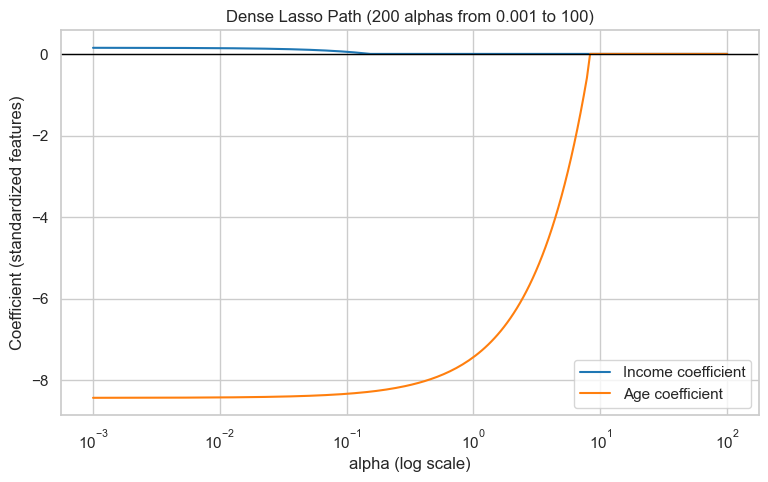

In [41]:
lasso_grid = reg_table[reg_table["Model"] == "Lasso"].reset_index(drop=True)
zeroed = lasso_grid[(lasso_grid["coef_Income"] == 0.0) | (lasso_grid["coef_Age"] == 0.0)]
first = zeroed.iloc[0]
first_feats = [f for f in ["coef_Income", "coef_Age"] if first[f] == 0.0]
print(f"On the grid {ALPHAS}, Lasso first sets a coefficient to exactly 0 at alpha = {first['alpha']}: {first_feats}")

# Dense path to locate the transitions more precisely
dense_alphas = np.logspace(-3, 2, 200)
dense = pd.DataFrame([fit_reg(Lasso(alpha=a, max_iter=100_000)) for a in dense_alphas], index=dense_alphas)
for feat in ["coef_Income", "coef_Age"]:
    is_zero = dense[feat] == 0.0
    # smallest alpha from which the coefficient stays exactly zero
    stays_zero = is_zero[::-1].cummin()[::-1]
    print(f"{feat}: exactly 0 from alpha = {stays_zero.idxmax():.4f} onward (dense grid)")

fig, ax = plt.subplots(figsize=(9, 5))
for i, (feat, label) in enumerate([("coef_Income", "Income"), ("coef_Age", "Age")]):
    ax.plot(dense.index, dense[feat], color=PALETTE[i], label=f"{label} coefficient")
ax.axhline(0, color="black", linewidth=1)
ax.set(xscale="log", title="Dense Lasso Path (200 alphas from 0.001 to 100)", xlabel="alpha (log scale)",
       ylabel="Coefficient (standardized features)")
ax.legend()
plt.show()

### B1.7 L1 vs L2 regularization

Answer: on the grid [0.01, 0.1, 1, 10, 100], Lasso first sets a coefficient to exactly zero at alpha = 1, and it is the Income coefficient (the Age coefficient is still -7.4290). On the dense grid, the Income coefficient is exactly 0 from alpha = 0.1534 onward and the Age coefficient from alpha = 8.3099 onward. From alpha = 10 both are zero and Lasso predicts the mean for everyone (R² = 0.0000).

L1 vs L2:

- Ridge (L2) shrinks the coefficients smoothly towards zero but never makes them exactly zero. Even at alpha = 100 Ridge keeps Income at 0.1236 and Age at -5.6183 (down from 0.1506 and -8.4271).
- Lasso (L1) cuts off weak coefficients exactly at zero, which is automatic feature selection. The L1 penalty has a corner at zero, so once the penalty outweighs how much a feature improves the fit, the optimal coefficient is exactly 0 rather than a small number.
- Lasso removes Income first because it is almost useless for predicting Spending Score. Its correlation with Spending Score is only 0.010 (Stage 1), and its coefficient in the plain linear model is just 0.1506, compared with -8.4271 for Age (correlation -0.327). A tiny penalty is enough to remove Income, while Age survives until alpha is about 8.3.
- The same alpha does not mean the same strength for both models. scikit-learn's Lasso minimizes (1 / (2n)) times the squared error plus alpha times the L1 norm, while Ridge minimizes the plain squared error (no 1 / (2n)) plus alpha times the squared L2 norm. With n = 200, Ridge's penalty is relatively much weaker at the same alpha. That is part of why Ridge barely moves until alpha = 10 while Lasso has already removed everything.
- R²: the plain linear model reaches only R² = 0.1071, so Income and Age together explain about 10.7% of the variance in Spending Score. This fits Stage 1: the relationship between these features and spending is grouped and non-linear (the corner groups in the income vs spending plot), which a straight line cannot capture but clustering can.

## Bonus 2: Hierarchical Clustering as a Sanity Check

### B2.1 Ward linkage

I use Ward linkage. At every step it merges the two clusters that give the smallest increase in total within-cluster variance, which is the same objective K-Means minimizes (WCSS). So a difference between the two methods reflects greedy agglomerative merging versus iterative centroid updates, not a different definition of a good cluster. I compute the linkage on the same `X_high` used in Stage 2.

In [42]:
Z = linkage(X_high, method="ward")
print("Linkage matrix shape:", Z.shape)

Linkage matrix shape: (199, 4)


### B2.2 Dendrograms

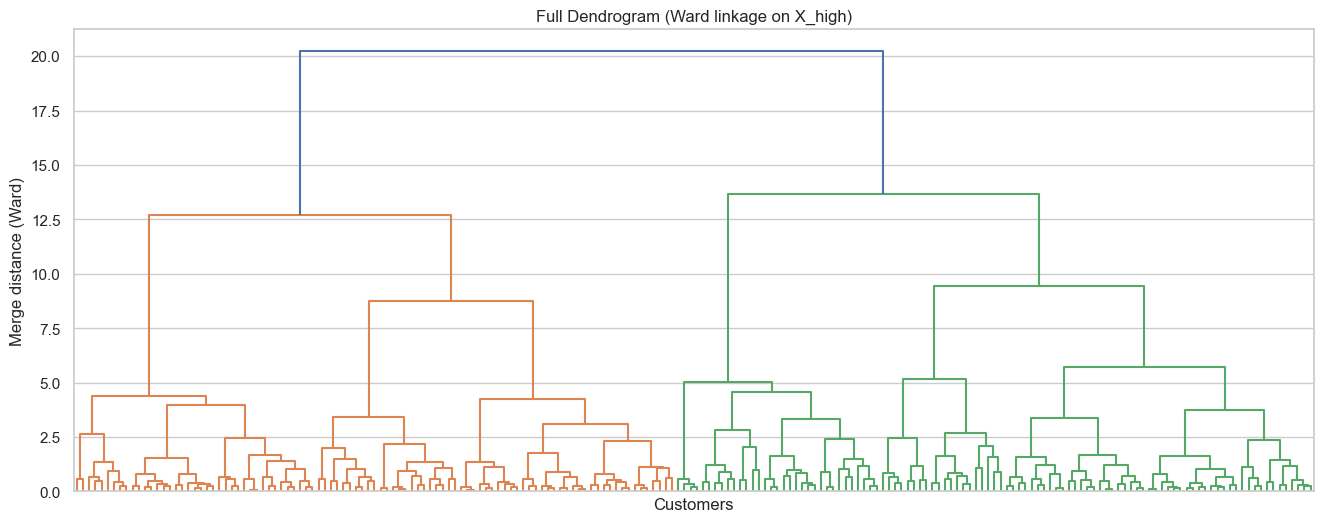

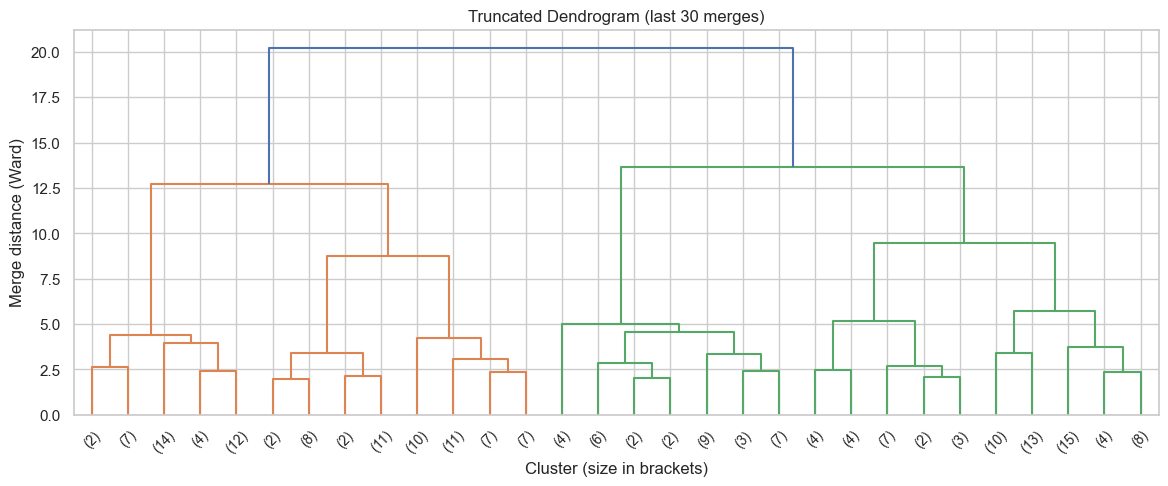

In [43]:
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set(title="Full Dendrogram (Ward linkage on X_high)", xlabel="Customers", ylabel="Merge distance (Ward)")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, show_leaf_counts=True)
ax.set(title="Truncated Dendrogram (last 30 merges)", xlabel="Cluster (size in brackets)", ylabel="Merge distance (Ward)")
plt.show()

### B2.3 Natural number of groupings from the merge heights

,Clusters if cut here,Lower merge height,Upper merge height,Gap
0,2,13.674,20.213,6.538
1,4,9.451,12.712,3.260
2,6,5.729,8.732,3.003
3,3,12.712,13.674,0.963
4,5,8.732,9.451,0.719
5,7,5.144,5.729,0.584
6,9,4.560,5.009,0.449
7,10,4.385,4.560,0.175
8,8,5.009,5.144,0.136


Largest gap -> 2 clusters; second largest gap -> 4 clusters


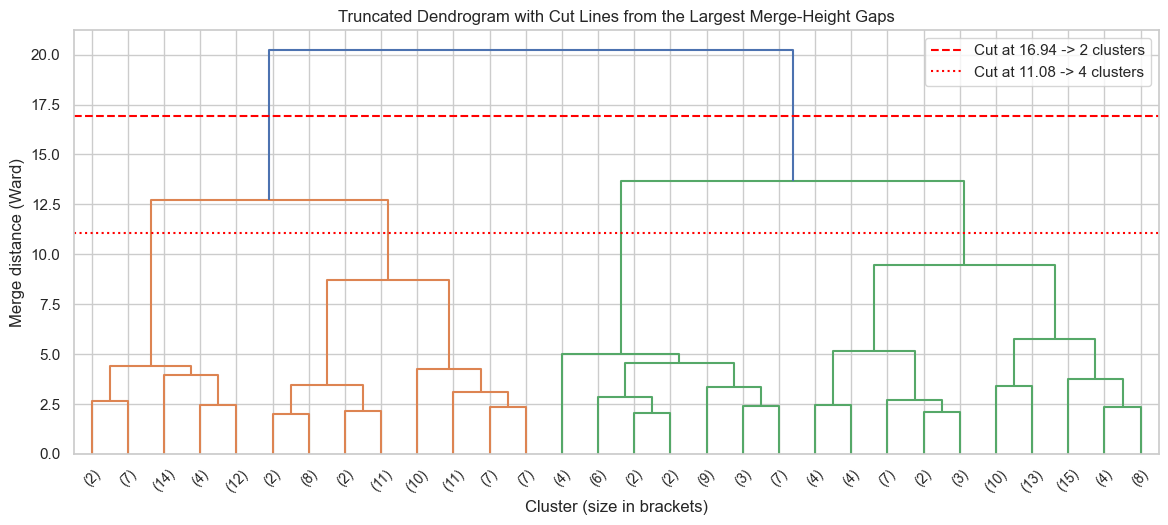

In [44]:
heights = Z[:, 2]
last = heights[-10:]
# cutting between last[i] and last[i + 1] leaves 10 - i clusters
gap_table = pd.DataFrame({
    "Clusters if cut here": [10 - i for i in range(9)],
    "Lower merge height": last[:-1],
    "Upper merge height": last[1:],
    "Gap": np.diff(last),
}).sort_values("Gap", ascending=False).reset_index(drop=True)
display(gap_table.round(3))

k_dendro = int(gap_table.loc[0, "Clusters if cut here"])
k_dendro_2 = int(gap_table.loc[1, "Clusters if cut here"])
cuts = {k: gap_table.loc[i, ["Lower merge height", "Upper merge height"]].mean() for i, k in enumerate([k_dendro, k_dendro_2])}
print(f"Largest gap -> {k_dendro} clusters; second largest gap -> {k_dendro_2} clusters")

fig, ax = plt.subplots(figsize=(14, 5.5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, show_leaf_counts=True)
for (k, h), style in zip(cuts.items(), ["--", ":"]):
    ax.axhline(h, color="red", linestyle=style, label=f"Cut at {h:.2f} -> {k} clusters")
ax.set(title="Truncated Dendrogram with Cut Lines from the Largest Merge-Height Gaps",
       xlabel="Cluster (size in brackets)", ylabel="Merge distance (Ward)")
ax.legend()
plt.show()

The merge heights put numbers on what the dendrogram shows. Among the last 10 merges:

- The largest gap (6.538, between heights 13.674 and 20.213) says that the most natural cut gives 2 clusters.
- The second largest gap (3.260, between 9.451 and 12.712) gives 4 clusters.
- The third largest gap (3.003, between 5.729 and 8.732) gives 6 clusters. It is almost as large as the 4-cluster gap.

A 2-cluster cut is the coarsest split and usually too broad for marketing, so I also fit the 2- and 4-cluster versions below and compare them with K = 6.

### B2.4 Agglomerative Clustering

In [45]:
labels_agg = AgglomerativeClustering(n_clusters=K_high, linkage="ward").fit_predict(X_high)
print(f"Agglomerative (K = {K_high}) cluster sizes:")
print(pd.Series(labels_agg).value_counts().sort_index())

extra_ks = sorted({k_dendro, k_dendro_2} - {K_high})
labels_agg_extra = {k: AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_high) for k in extra_ks}
for k, lab in labels_agg_extra.items():
    print(f"\nAgglomerative (K = {k}, suggested by the dendrogram) cluster sizes:")
    print(pd.Series(lab).value_counts().sort_index())

Agglomerative (K = 6) cluster sizes:
0    50
1    20
2    33
3    39
4    35
5    23
Name: count, dtype: int64

Agglomerative (K = 2, suggested by the dendrogram) cluster sizes:
0    103
1     97
Name: count, dtype: int64

Agglomerative (K = 4, suggested by the dendrogram) cluster sizes:
0    70
1    58
2    33
3    39
Name: count, dtype: int64


### B2.5 Comparison with the Stage 2 K-Means result

In [46]:
ct_agg = pd.crosstab(pd.Series(labels_high, name="K-Means"), pd.Series(labels_agg, name="Agglomerative"))
display(ct_agg)

scores = [{"Method": f"K-Means (K = {K_high})", "Silhouette (X_high)": sil_high, "ARI vs K-Means": 1.0},
          {"Method": f"Agglomerative Ward (K = {K_high})", "Silhouette (X_high)": silhouette_score(X_high, labels_agg),
           "ARI vs K-Means": adjusted_rand_score(labels_high, labels_agg)}]
for k, lab in labels_agg_extra.items():
    scores.append({"Method": f"Agglomerative Ward (K = {k})", "Silhouette (X_high)": silhouette_score(X_high, lab),
                   "ARI vs K-Means": adjusted_rand_score(labels_high, lab)})
display(pd.DataFrame(scores).round(4))

# Match every K-Means cluster with the Agglomerative cluster it overlaps most
match = ct_agg.idxmax(axis=1)
prof_km = df_original.groupby(labels_high)[NUM_COLS].mean()
prof_agg = df_original.groupby(labels_agg)[NUM_COLS].mean()
comparison = pd.concat({
    "K-Means": prof_km.assign(Size=pd.Series(labels_high).value_counts()),
    "Agglomerative (matched)": prof_agg.loc[match.values].set_axis(prof_km.index)
                                       .assign(Size=pd.Series(labels_agg).value_counts().loc[match.values].values),
}, axis=1).round(1)
comparison.insert(0, ("Match", "Agg cluster"), match.values)
comparison.index.name = "K-Means cluster"
comparison

Agglomerative,0,1,2,3,4,5
K-Means,,,,,,
0,44,0,1,0,0,0
1,0,0,0,39,0,0
2,2,19,0,0,0,0
3,2,0,32,0,0,0
4,0,1,0,0,0,22
5,2,0,0,0,35,1


,Method,Silhouette (X_high),ARI vs K-Means
0,K-Means (K = 6),0.3565,1.0000
1,Agglomerative Ward (K = 6),0.3504,0.8917
2,Agglomerative Ward (K = 2),0.2923,0.3310
3,Agglomerative Ward (K = 4),0.3299,0.6710


Match K-Means                                            \
                Agg cluster     Age Annual Income (k$) Spending Score (1-100)   
K-Means cluster                                                                 
0                         0    56.3               54.3                   49.1   
1                         3    32.7               86.5                   82.1   
2                         1    45.5               26.3                   19.4   
3                         2    41.3               88.5                   16.8   
4                         5    25.0               25.3                   77.6   
5                         4    27.0               56.7                   49.1   

                     Agglomerative (matched)                     \
                Size                     Age Annual Income (k$)   
K-Means cluster                                                   
0                 45                    55.0               53.6   
1                 39                    32.7               86.5   
2                 21                    43.8               25.2   
3                 34                    41.5               89.1   
4                 23                    25.6               26.4   
5                 38                    26.1               57.2   

                                             
                Spending Score (1-100) Size  
K-Means cluster                              
0                                 48.2   50  
1                                 82.1   39  
2                                 19.0   20  
3                                 16.2   33  
4                                 78.5   23  
5                                 48.7   35

### B2.6 Answers

Natural number of groupings vs the chosen K: the largest gap in merge heights suggests 2 groups, the second largest 4, and the third largest (3.003, almost equal to the second at 3.260) gives 6. So the dendrogram does not point cleanly to K = 6. It shows a hierarchy: 2 broad groups at the top, 4 at a finer level and 6 at the next level. The Silhouette Scores in `X_high` favour the finer level: Ward with K = 2 scores 0.2923 and K = 4 scores 0.3299, while Ward with K = 6 scores 0.3504, close to K-Means at K = 6 (0.3565). This matches Stage 2, where K = 6 had the highest silhouette and K = 4 was the runner-up. The dendrogram is consistent with my choice of K = 6, but it also shows that K = 4 is a reasonable coarser segmentation.

Do the profiles agree? Yes, roughly. At K = 6, Ward and K-Means reach an Adjusted Rand Index of 0.8917, and every K-Means cluster has a clear majority match in the crosstab. The matched profiles in B2.5 differ by at most 1.7 years in mean age, 1.1k in mean income and 0.9 points in mean spending score. Affluent Big Spenders (K-Means cluster 1) match exactly (39 customers, same means). The main difference is the Mature Moderate Spenders segment (K-Means cluster 0): Ward assigns it 50 customers instead of 45, taking 2 boundary customers each from the Budget-Conscious (cluster 2), Careful High-Earners (cluster 3) and Young Mainstream (cluster 5) segments. That pulls its mean age down from 56.3 to 55.0. These are borderline customers, the same kind that had low silhouette values in 4.3. The six segments are the same; only a few customers near the boundaries switch.

## Bonus 3: Initialization Stability

### B3.1 The default n_init in the installed scikit-learn

In [47]:
print("scikit-learn version:", sklearn.__version__)
print("Default KMeans n_init:", repr(KMeans().get_params()["n_init"]))
doc = KMeans.__doc__
print(doc[doc.index("n_init :"):doc.index("max_iter :")])

scikit-learn version: 1.8.0
Default KMeans n_init: 'auto'
n_init : 'auto' or int, default='auto'
    Number of times the k-means algorithm is run with different centroid
    seeds. The final results is the best output of `n_init` consecutive runs
    in terms of inertia. Several runs are recommended for sparse
    high-dimensional problems (see :ref:`kmeans_sparse_high_dim`).

    When `n_init='auto'`, the number of runs depends on the value of init:
    10 if using `init='random'` or `init` is a callable;
    1 if using `init='k-means++'` or `init` is an array-like.

    .. versionadded:: 1.2
       Added 'auto' option for `n_init`.

    .. versionchanged:: 1.4
       Default value for `n_init` changed to `'auto'`.




### B3.2 Ten seeds with n_init=1 vs n_init=10

In [48]:
def run_seeds(setting, **kw):
    """Final WCSS of K-Means on X_high (K = K_high) for seeds 0..9."""
    return pd.DataFrame([{"Setting": setting, "Seed": s,
                          "WCSS": KMeans(n_clusters=K_high, random_state=s, **kw).fit(X_high).inertia_}
                         for s in range(10)])


runs = pd.concat([run_seeds("n_init=1", n_init=1), run_seeds("n_init=10", n_init=10)], ignore_index=True)
runs.pivot(index="Seed", columns="Setting", values="WCSS").round(4)

Setting,n_init=1,n_init=10
Seed,,
0,194.0042,181.9514
1,194.5134,181.9514
2,181.9514,181.9514
3,196.0174,181.9514
4,181.9514,181.9514
5,181.9514,181.9514
6,182.2268,181.9514
7,181.9514,181.9514
8,218.3728,181.9514


### B3.3 Variability summary

In [49]:
def summarize(runs):
    g = runs.groupby("Setting", sort=False)["WCSS"]
    s = g.agg(["mean", "std", "min", "max"])
    s["range"] = s["max"] - s["min"]
    s["distinct values"] = g.apply(lambda w: w.round(4).nunique())
    return s


display(summarize(runs).round(4))
best_wcss = runs["WCSS"].min()
print(f"Best WCSS found overall: {best_wcss:.4f}")
single = runs[runs["Setting"] == "n_init=1"].assign(
    **{"Reached best WCSS": lambda d: np.isclose(d["WCSS"], best_wcss)})
single[["Seed", "WCSS", "Reached best WCSS"]].round(4)

,mean,std,min,max,range,distinct values
Setting,,,,,,
n_init=1,191.0718,11.7671,181.9514,218.3728,36.4214,7
n_init=10,181.9514,0.0000,181.9514,181.9514,0.0000,1


Best WCSS found overall: 181.9514


,Seed,WCSS,Reached best WCSS
0,0,194.0042,False
1,1,194.5134,False
2,2,181.9514,True
3,3,196.0174,False
4,4,181.9514,True
5,5,181.9514,True
6,6,182.2268,False
7,7,181.9514,True
8,8,218.3728,False
9,9,197.7780,False


### B3.4 Visualizing the variability

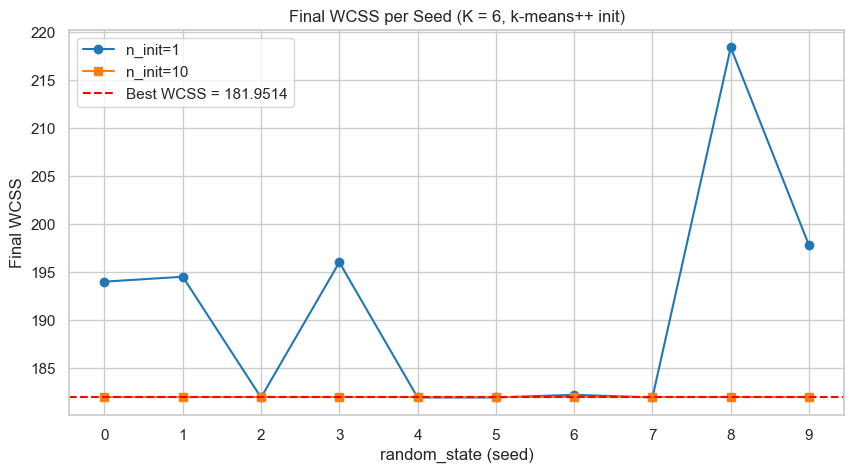

In [50]:
def plot_runs(runs, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    markers = ["o", "s", "^"]
    for i, (setting, sub) in enumerate(runs.groupby("Setting", sort=False)):
        ax.plot(sub["Seed"], sub["WCSS"], marker=markers[i], color=PALETTE[i], label=setting)
    ax.axhline(runs["WCSS"].min(), color="red", linestyle="--", label=f"Best WCSS = {runs['WCSS'].min():.4f}")
    ax.set(title=title, xlabel="random_state (seed)", ylabel="Final WCSS", xticks=range(10))
    ax.legend()
    plt.show()


plot_runs(runs, f"Final WCSS per Seed (K = {K_high}, k-means++ init)")

### B3.5 Extra check: single random initialization (init="random", n_init=1)

,mean,std,min,max,range,distinct values
Setting,,,,,,
n_init=1,191.0718,11.7671,181.9514,218.3728,36.4214,7
n_init=10,181.9514,0.0000,181.9514,181.9514,0.0000,1
"n_init=1, init=""random"" (extra)",200.2506,10.4690,181.9514,208.2918,26.3404,9


Best WCSS over all settings: 181.9514
Runs reaching the best WCSS per setting:
Setting
n_init=1                            4
n_init=10                          10
n_init=1, init="random" (extra)     1
Name: best, dtype: int64


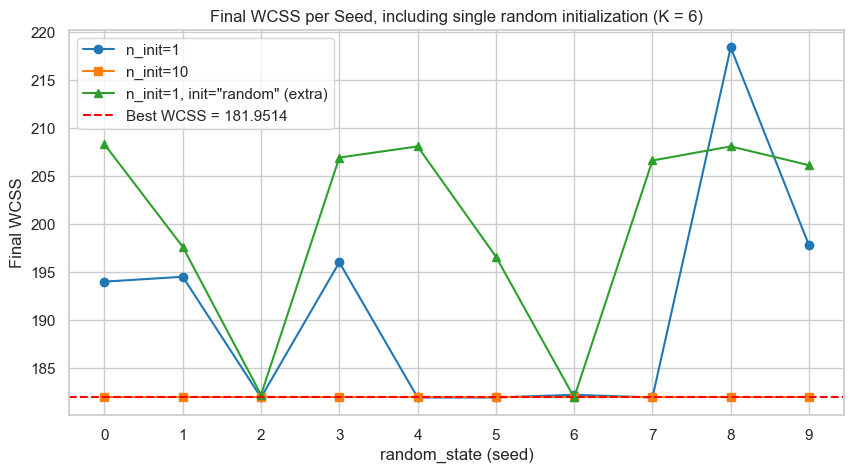

In [51]:
runs_all = pd.concat([runs, run_seeds('n_init=1, init="random" (extra)', n_init=1, init="random")], ignore_index=True)
display(summarize(runs_all).round(4))
best_all = runs_all["WCSS"].min()
print(f"Best WCSS over all settings: {best_all:.4f}")
print("Runs reaching the best WCSS per setting:")
print(runs_all.assign(best=np.isclose(runs_all["WCSS"], best_all)).groupby("Setting", sort=False)["best"].sum())
plot_runs(runs_all, f"Final WCSS per Seed, including single random initialization (K = {K_high})")

### B3.6 Discussion

What the experiment shows: K-Means only finds a local optimum, and which optimum it reaches depends on the starting centroids. With a single k-means++ initialization (n_init=1), the 10 seeds produced 7 distinct WCSS values, from 181.9514 to 218.3728 (mean 191.0718, standard deviation 11.7671, range 36.4214). Only 4 of the 10 runs (seeds 2, 4, 5 and 7) reached the best WCSS of 181.9514, and the worst run (seed 8) was about 20% worse. With n_init=10, every seed reached exactly 181.9514 (standard deviation 0, 1 distinct value). Running several initializations and keeping the one with the lowest WCSS makes the result both better and reproducible, whatever the seed. This is why I used n_init=10 throughout.

The extra check with `init="random"` and n_init=1 is worse on average: mean WCSS 200.2506, 9 distinct values out of 10 runs, and only 1 of the 10 runs reached the best solution. k-means++ spreads the initial centroids out, which improves the starting point on average (mean 191.0718 vs 200.2506). But it does not guarantee a good run: the single worst run in the whole experiment (218.3728) came from k-means++. Seeding reduces the need for restarts, but it does not remove it.

The default in the installed scikit-learn: this notebook runs scikit-learn 1.8.0, where `KMeans().get_params()["n_init"]` prints `'auto'`. According to the docstring printed in B3.1, `'auto'` means 1 run when `init='k-means++'` (the default init) or an array, and 10 runs when `init='random'` or a callable. The `'auto'` option was added in version 1.2 and became the default in version 1.4; before that, the default was 10 runs for every init. So a plain `KMeans(n_clusters=6)` in this version does only one k-means++ initialization, which is the n_init=1 setting above. In my experiment, 6 of 10 seeds would then have given a worse clustering. For stable results I set n_init explicitly (n_init=10) instead of relying on the default.

## Conclusion

- Stage 2 (`X_high`, 4 features): the Elbow Method and the Silhouette Score both pointed to K_high = 6, with a final Silhouette Score of 0.3565 (weak but real structure by the Kaufman and Rousseeuw rule of thumb).
- Stage 3 (PCA): 3 components explain 92.49% of the variance, and the dropped component is essentially Gender. On `X_pca` I chose K_pca = 6, with a Silhouette Score of 0.4275 in the PCA space. The same labels score 0.3570 in `X_high`.
- Comparison: the two clusterings are almost identical (ARI 0.9772, only 2 of 200 customers differ), and in the same space their silhouettes differ by only 0.0005. I chose the Stage 2 clustering because it uses all the information with one fewer transformation. The higher PCA score comes from measuring in a smaller space, not from better clusters.
- Personas:
  - Cluster 0, Mature Moderate Spenders: age 56.3, income 54.3k, spending 49.1, 45 customers.
  - Cluster 1, Affluent Big Spenders: age 32.7, income 86.5k, spending 82.1, 39 customers.
  - Cluster 2, Budget-Conscious Shoppers: age 45.5, income 26.3k, spending 19.4, 21 customers.
  - Cluster 3, Careful High-Earners: age 41.3, income 88.5k, spending 16.8, 34 customers.
  - Cluster 4, Young Impulsive Spenders: age 25.0, income 25.3k, spending 77.6, 23 customers.
  - Cluster 5, Young Mainstream Shoppers: age 27.0, income 56.7k, spending 49.1, 38 customers.
- Bonus 1: Lasso first zeroes the Income coefficient at alpha = 1 on the grid (0.1534 on the dense grid), and Age at 8.3099. Ridge only shrinks both. The linear model reaches R² = 0.1071, so the structure is grouped rather than linear.
- Bonus 2: Ward's largest merge gaps suggest 2, then 4, then 6 groups. Ward with K = 6 agrees with K-Means (ARI 0.8917, silhouette 0.3504 vs 0.3565) and gives the same six segment profiles, with a few boundary customers reassigned.
- Bonus 3: with n_init=1, only 4 of 10 seeds reached the best WCSS (181.9514) and the worst reached 218.3728, while n_init=10 reached 181.9514 every time. scikit-learn 1.8.0's default n_init is `'auto'`, which means only one run with k-means++, so I set n_init explicitly.